<a href="https://colab.research.google.com/github/replysantosh-lang/ECARDeepLearning/blob/main/DAY03/Data_Augmentation_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable weights before freezing: 30
Trainable weights after freezing: 4
Found 3598 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Epoch 1/30
 92/100 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.6338 - loss: 0.6341

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


100/100 ━━━━━━━━━━━━━━━━━━━━ 694s 7s/step - accuracy: 0.7046 - loss: 0.5765 - val_accuracy: 0.8575 - val_loss: 0.3926
Epoch 2/30
  1/100 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.7188 - loss: 0.5432

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.7716 - loss: 0.5063 - val_accuracy: 0.8600 - val_loss: 0.3878
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 833ms/step - accuracy: 0.7954 - loss: 0.4586 - val_accuracy: 0.8925 - val_loss: 0.3159
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.8317 - loss: 0.4276 - val_accuracy: 0.8875 - val_loss: 0.3105
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 442ms/step - accuracy: 0.8108 - loss: 0.4140 - val_accuracy: 0.9000 - val_loss: 0.2824
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8438 - loss: 0.3633 - val_accuracy: 0.9000 - val_loss: 0.2784
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 381ms/step - accuracy: 0.8294 - loss: 0.3848 - val_accuracy: 0.9050 - val_loss: 0.2612
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.8719 - loss: 0.3349 - val_accuracy: 0.8975 - val_loss: 0.2733
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 77s 393ms/step - accuracy: 0.8394 - loss: 0.3670 - val_accur

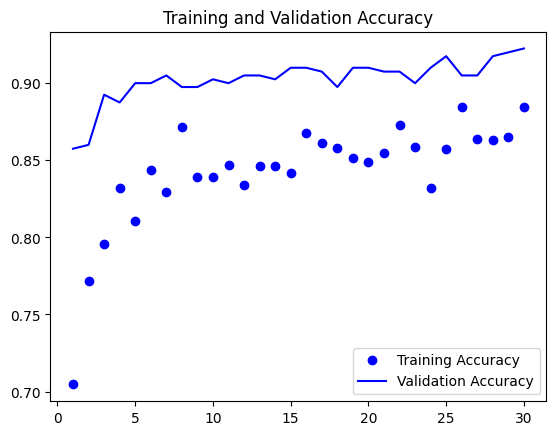

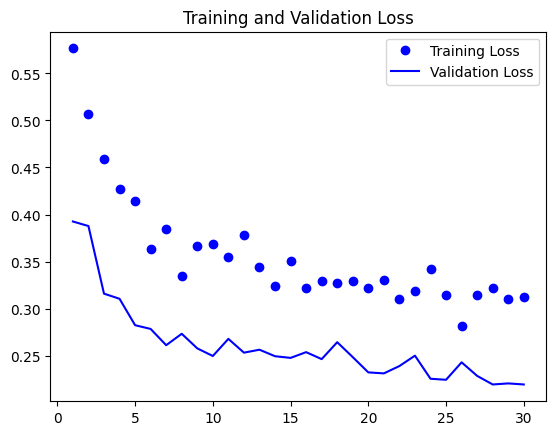

In [3]:
# This method allows Data Augmentation (GPU recommended)

from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Load pretrained VGG16 convolutional base
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

# Build model
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

# Freeze convolutional base
print("Trainable weights before freezing:", len(model.trainable_weights))
conv_base.trainable = False
print("Trainable weights after freezing:", len(model.trainable_weights))

# Dataset directories
train_dir="/content/drive/MyDrive/cats_dogs_dataset/cats_dogs_dataset/train/"
validation_dir="/content/drive/MyDrive/cats_dogs_dataset/cats_dogs_dataset/validation/"


# Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Only rescale validation data
test_datagen = ImageDataGenerator(rescale=1./255)

# Training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

# Validation generator
validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

# Compile model
model.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=2e-5),
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)

# Plot results
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'bo', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()